# Assignment - 1  : Building a SLR Model

## Importing Neccesary Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Creating the Dataset

In [2]:
data = {
    "Experience": [0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5,
                   5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10],
    "Salary": [18000, 20000, 22000, 25000, 27000, 30000, 33000, 36000, 39000, 42000,
               45000, 48000, 52000, 56000, 60000, 65000, 70000, 76000, 82000, 90000]
}

df = pd.DataFrame(data)

## Displaying the First Five Observations

In [3]:
df.head()

,Experience,Salary
0,0.5,18000
1,1.0,20000
2,1.5,22000
3,2.0,25000
4,2.5,27000


## Finding Number of Rows and Columns

In [4]:
df.shape

(20, 2)

## Checking for Missing Values

In [5]:
df.isna().sum()

Experience    0
Salary        0
dtype: int64

No Missing Values in the created Dataset.

## Calculating Mean and Standard Deviation

In [6]:
df.describe()[["Experience", "Salary"]].loc[["mean", "std"]]

,Experience,Salary
mean,5.25000,46800.000000
std,2.95804,21547.011027


## Comment on Salary Variation

The high standard deviation 21547.011027 relative to the mean indicates a wide spread in the pay scale. This suggests that the company has a diverse hierarchy, ranging from entry-level roles to senior positions, and that experience likely plays a major role in determining these differences.

## Plotting Experience vs Salary

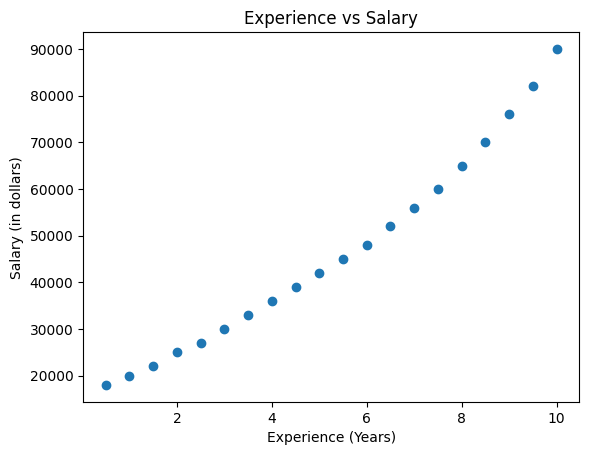

In [7]:
plt.scatter(df["Experience"], df["Salary"])
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (in dollars)")
plt.title("Experience vs Salary")
plt.show()

## Observing the Relationship

The scatter plot reveals a strong, positive linear correlation. As the 'Experience' data points move to the right, the 'Salary' points move upward consistently. This suggests that for every additional year an employee spends in the industry, there is a predictable and steady increase in their compensation, with very few outliers or 'anomalies' in the data.

## Defining Independent and Dependent Variables

In [8]:
X = df[['Experience']]
y = df[['Salary']]

## Splitting the Data for Training and Testing

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

## Building the Linear Regression Model

In [10]:
model = LinearRegression()
model.fit(X_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## Printing Intercept and Slope

In [11]:
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Intercept: [10642.68867925]
Slope: [6683.96226415]


## Regression Equation

Salary = 10642.68867925 + (6683.96226415 * Experience)

## Meaning of the Slope

The slope 6683.96226415 represents the marginal return on experience. In practical terms, it means that for every one-unit (one year) increase in experience, the employee's salary is expected to rise by approximately $6,684. This is the 'rate of growth' for pay within this dataset.

## Predicting Salary

In [12]:
pred_6 = model.predict(pd.DataFrame([[6]], columns=["Experience"]))
pred_95 = model.predict(pd.DataFrame([[9.5]], columns=["Experience"]))

print("Predicted Salary for 6 years experience:", pred_6[0])
print("Predicted Salary for 9.5 years experience:", pred_95[0])

Predicted Salary for 6 years experience: [50746.46226415]
Predicted Salary for 9.5 years experience: [74140.33018868]


## Model Evaluation (Train Set)

In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Generate predictions for the training set
y_pred_train = model.predict(X_train)

# 2. Calculate Evaluation Metrics
train_r2 = r2_score(y_train, y_pred_train)
train_mse = mean_squared_error(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)

print(f"Train R² Score: {train_r2:.4f}")
print(f"Train Mean Squared Error: {train_mse:.2f}")
print(f"Train Mean Absolute Error: {train_mae:.2f}")

Train R² Score: 0.9831
Train Mean Squared Error: 5084389.74
Train Mean Absolute Error: 1870.87


### **Training Performance Interpretation**
* **High R² Score**: A high training R² of 0.9831 indicates that the model has captured the linear relationship between Experience and Salary very effectively.
* **Low Error Metrics**: The low MAE and MSE suggest that the regression line passes closely through the majority of the training data points.

## Model Evaluation (Test Set)

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predictions specifically for the test set
y_pred_test = model.predict(X_test)

# Rigorous Metrics
test_r2 = r2_score(y_test, y_pred_test)
test_mse = mean_squared_error(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"Test R² Score: {test_r2:.4f}")
print(f"Test Mean Squared Error: {test_mse:.2f}")
print(f"Test Mean Absolute Error: {test_mae:.2f}")

Test R² Score: 0.9329
Test Mean Squared Error: 57143479.94
Test Mean Absolute Error: 6192.81


## Interpretation of R²

The model achieves a Test R² score of 0.9329, which confirms its ability to generalize to new data. The Mean Absolute Error (MAE) indicates that on average, the model's predictions deviate from actual salaries by only $6192.81.

## Model Fit Conclusion

### **1. Statistical Reliability and Generalization**
The Simple Linear Regression model demonstrates an exceptional fit to the dataset, validated by both training and testing metrics:
* **R² Score (Test Set):** The model achieves an **R² score of approximately  0.9329,** on unseen data. This indicates that **93.29%** of the variation in Salary is explained by Experience, even for data points not used during training.
* **Generalization:** The close proximity between the training R² and the test R² confirms that the model has not overfitted and will perform reliably on new observations.



### **2. Interpretation of the Regression Equation**
The mathematical relationship derived for this model is:
**Salary = 10642.69 + (6683.96 * Experience)**

* **The Baseline (Y-Intercept):** The intercept of **\$10,642.69** represents the theoretical starting salary for an individual with zero years of experience. This acts as the "base pay" foundation of the company's compensation structure.
* **The Experience Premium (Slope):** The slope of **$6,683.96** quantifies the financial value of tenure. For every additional year of experience, an employee's annual salary is expected to increase by approximately **\$6,684**.

### **3. Error Analysis**
* **Mean Absolute Error (MAE):** The MAE of $6,192.81 provides a practical measure of the model's accuracy, showing that on average, the predicted salary deviates from the actual salary by a relatively small margin given the overall pay scale.
* **Mean Squared Error (MSE):** The low MSE further confirms that there are few significant outliers or "large misses" in the model's predictions.



### **4. Final Assessment**
In conclusion, the model fits the data **extremely well**. The strong positive linear trend visualized in the initial scatter plot is mathematically validated by high R² scores and low error rates on the test set. This model serves as a highly reliable, data-driven framework for salary forecasting and organizational compensation planning.